# Table of Contents

- Importing libraries
- kNN vs Dimensions
- Decision Tree vs Dimensions
- SVM vs Dimensions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# kNN vs Dimensions
<a name="ZQRX6E9uNccS"></a>


Processing D = 2 features (n_samples=5000)...
Optimal k found: 12. (Best CV Score: 0.9194)

Processing D = 3 features (n_samples=5000)...
Optimal k found: 12. (Best CV Score: 0.9358)

Processing D = 9 features (n_samples=5000)...
Optimal k found: 13. (Best CV Score: 0.9632)

Processing D = 10 features (n_samples=5000)...
Optimal k found: 17. (Best CV Score: 0.9706)


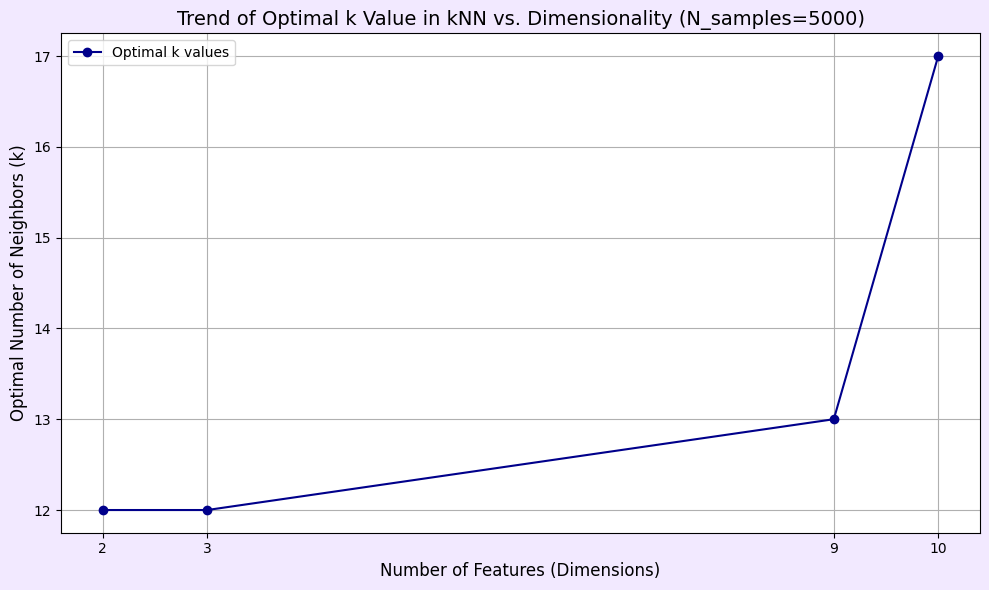

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# -------------------------------
# Experiment Parameters
# -------------------------------
n = 5000  # Number of samples in synthetic dataset
randomseed = 42  # Ensures reproducibility of random dataset generation
dimensions_to_test = [2, 3, 9, 10]  # List of feature dimensionalities to test
K_range = [12, 13, 14, 15, 16, 17]  # Candidate k values for kNN
optimal_k_results = {}  # Dictionary to store optimal k for each dimensionality

# -------------------------------
# Loop Over Different Dimensionalities
# -------------------------------
for D in dimensions_to_test:
    print(f"\nProcessing D = {D} features (n_samples={n})...")

    # Generate synthetic dataset for this dimensionality
    # n_informative=min(D, 10) ensures no more informative features than dimensions
    # n_redundant=0 avoids redundant features for clarity
    X, y = make_classification(
        n_samples=n,
        n_features=D,
        n_informative=min(D, 10),
        n_redundant=0,
        random_state=randomseed
    )

    # Build pipeline: scaling is crucial because kNN uses distance metrics
    pipeline = make_pipeline(
        StandardScaler(),  # Normalize features to mean=0, std=1
        KNeighborsClassifier()  # kNN classifier; k will be tuned
    )

    # GridSearchCV automates selection of optimal k using cross-validation
    # 'kneighborsclassifier__n_neighbors' accesses k parameter inside the pipeline
    param_grid = {'kneighborsclassifier__n_neighbors': K_range}
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,  # 5-fold cross-validation gives stable estimate of accuracy
        scoring='accuracy',  # Optimize for classification accuracy
        n_jobs=-1  # Use all CPU cores
    )
    grid_search.fit(X, y)  # Fit pipeline + cross-validation

    # Record and display optimal k for this dimensionality
    optimal_k = grid_search.best_params_['kneighborsclassifier__n_neighbors']
    optimal_k_results[D] = optimal_k
    print(f"Optimal k found: {optimal_k}. (Best CV Score: {grid_search.best_score_:.4f})")

# -------------------------------
# Plot Optimal k vs Dimensionality
# -------------------------------
dimensions = list(optimal_k_results.keys())  # Feature counts
optimal_ks = list(optimal_k_results.values())  # Corresponding optimal k

plt.figure()
plt.plot(
    dimensions,
    optimal_ks,
    marker='o',
    linestyle='-',
    color='darkblue',
    label='Optimal k values'
)
plt.xlabel('Number of Features (Dimensions)')
plt.ylabel('Optimal Number of Neighbors (k)')
plt.title(f'Trend of Optimal k Value in kNN vs. Dimensionality (N_samples={n})')
plt.grid(True)
plt.xticks(dimensions, labels=dimensions)  # Ensure only tested dimensions are labeled
plt.legend()
plt.tight_layout()
plt.show()



---



# Decision tree vs Dimensions
<a name="IkBPYVOMN-Vq"></a>


Processing D = 2 features (n_samples=5000)...
Optimal depth found: 5. (Best CV Score: 0.9076)

Processing D = 3 features (n_samples=5000)...
Optimal depth found: 8. (Best CV Score: 0.9246)

Processing D = 4 features (n_samples=5000)...
Optimal depth found: 10. (Best CV Score: 0.8866)

Processing D = 5 features (n_samples=5000)...
Optimal depth found: 7. (Best CV Score: 0.9012)

Processing D = 6 features (n_samples=5000)...
Optimal depth found: 12. (Best CV Score: 0.8668)


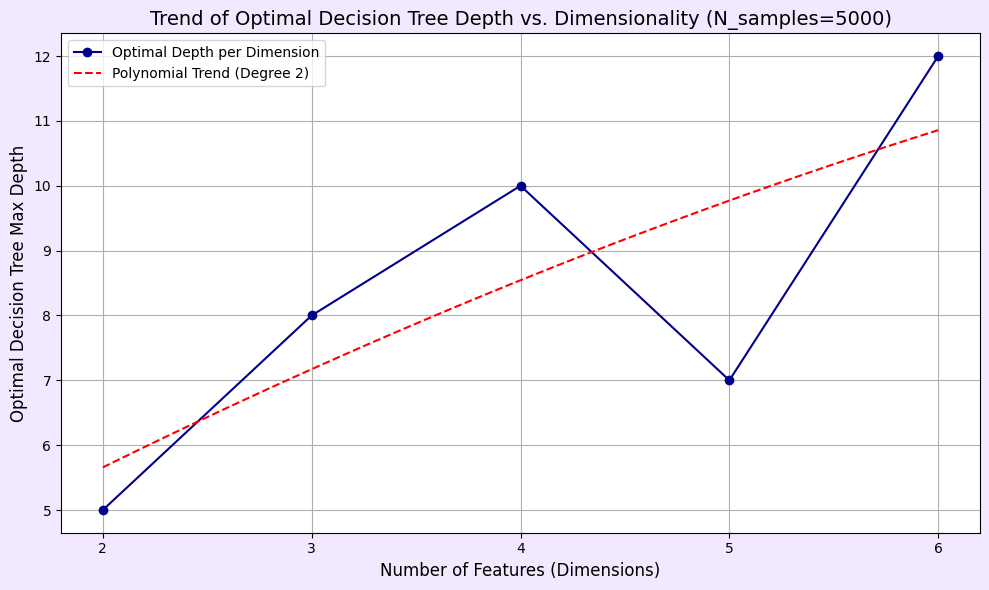

In [ ]:
# -------------------------------
# Experiment Parameters
# -------------------------------
n = 5000  # Number of samples in synthetic dataset
randomseed = 42  # Ensures reproducibility
dimensions_to_test = list(range(2, 7))  # Feature dimensionalities to test
depth_range = np.arange(1, 20)  # Candidate max_depth values for Decision Tree
optimal_depth_results = {}  # Dictionary to store optimal depth for each dimensionality

# -------------------------------
# Loop Over Different Dimensionalities
# -------------------------------
for D in dimensions_to_test:
    print(f"\nProcessing D = {D} features (n_samples={n})...")

    # Generate synthetic dataset for this dimensionality
    # n_informative=min(D, 10) ensures we don't have more informative features than dimensions
    # n_redundant=0 avoids extra redundant features for clarity
    X, y = make_classification(
        n_samples=n,
        n_features=D,
        n_informative=min(D, 10),
        n_redundant=0,
        random_state=randomseed
    )

    # Initialize Decision Tree classifier
    dtree = DecisionTreeClassifier(random_state=randomseed)

    # Use GridSearchCV to find optimal max_depth
    # cv=5 for 5-fold cross-validation
    # scoring='accuracy' to optimize classification performance
    param_grid = {'max_depth': depth_range}
    grid_search = GridSearchCV(dtree, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

    grid_search.fit(X, y)  # Fit model and evaluate cross-validation performance

    # Record and display the optimal max_depth for this dimensionality
    optimal_depth = grid_search.best_params_['max_depth']
    optimal_depth_results[D] = optimal_depth
    print(f"Optimal depth found: {optimal_depth}. (Best CV Score: {grid_search.best_score_:.4f})")

# -------------------------------
# Prepare Data for Plotting
# -------------------------------
dimensions = list(optimal_depth_results.keys())  # Feature counts
optimal_depths = list(optimal_depth_results.values())  # Corresponding optimal max_depths

# Convert to numpy arrays for polynomial fitting
dimensions_np = np.array(dimensions)
optimal_depths_np = np.array(optimal_depths)

# -------------------------------
# Polynomial Fit to Capture Trend
# -------------------------------
degree = 2  # Degree of polynomial for smoothing the trend
coeffs = np.polyfit(dimensions_np, optimal_depths_np, degree)
poly_function = np.poly1d(coeffs)

# Generate smooth trend line for plotting
x_trend = np.linspace(min(dimensions), max(dimensions), 100)
y_trend = poly_function(x_trend)

# -------------------------------
# Plot Optimal Depth vs Dimensionality
# -------------------------------
plt.figure()
plt.plot(
    dimensions,
    optimal_depths,
    marker='o',  # Marker for actual data points
    linestyle='-',  # Line connecting points
    color='darkblue',
    label='Optimal Depth per Dimension'
)
plt.plot(
    x_trend,
    y_trend,
    color='red',
    linestyle='--',
    label=f'Polynomial Trend (Degree {degree})'
)
plt.xlabel('Number of Features (Dimensions)')
plt.ylabel('Optimal Decision Tree Max Depth')
plt.title(f'Trend of Optimal Decision Tree Depth vs. Dimensionality (N_samples={n})')
plt.xticks(dimensions)  # Only show tested dimensions on x-axis
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



---



# SVM vs dimensions
<a name="H30CbSjWONCI"></a>


Processing D = 2 features (n_samples=5000)...
Optimal C found: 1000.0. (Best CV Score: 0.9128)

Processing D = 3 features (n_samples=5000)...
Optimal C found: 100.0. (Best CV Score: 0.9398)

Processing D = 4 features (n_samples=5000)...
Optimal C found: 100.0. (Best CV Score: 0.9358)

Processing D = 5 features (n_samples=5000)...
Optimal C found: 10.0. (Best CV Score: 0.9400)

Processing D = 6 features (n_samples=5000)...
Optimal C found: 3.1622776601683795. (Best CV Score: 0.9488)


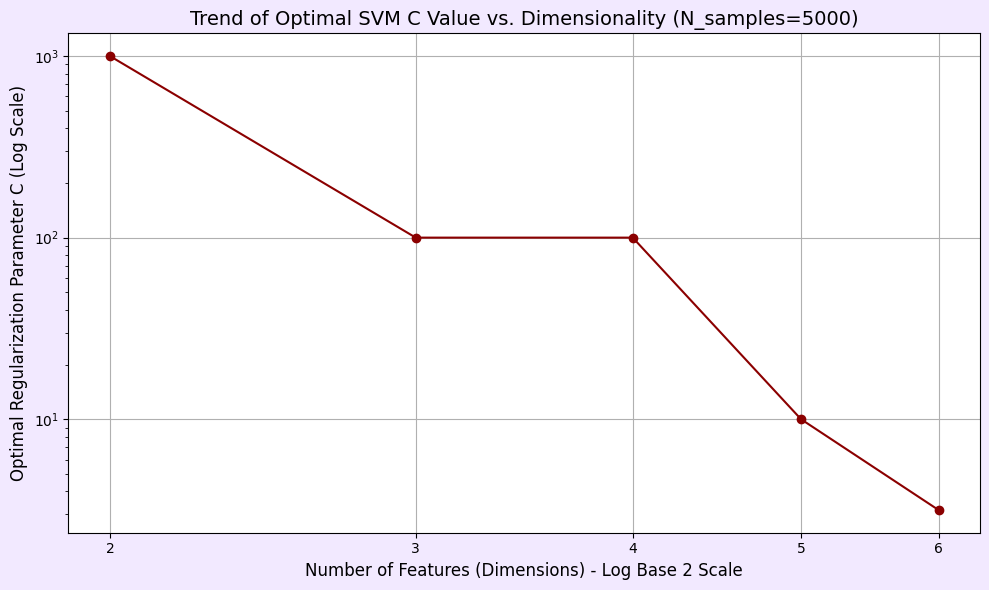

In [ ]:
# -------------------------------
# Experiment Parameters
# -------------------------------
n = 5000  # Number of samples in synthetic dataset
randomseed = 42  # Ensure reproducibility
dimensions_to_test = list(range(2, 7))  # Feature dimensionalities to test
C_range = np.logspace(-3, 3, 13)  # Candidate regularization parameter values (C) for SVM
optimal_c_results = {}  # Dictionary to store optimal C for each dimensionality

# -------------------------------
# Loop Over Different Dimensionalities
# -------------------------------
for D in dimensions_to_test:
    print(f"\nProcessing D = {D} features (n_samples={n})...")

    # Generate synthetic dataset for this dimensionality
    # n_informative=min(D, 10) ensures no more informative features than dimensions
    # n_redundant=0 avoids redundant features for clarity
    X, y = make_classification(
        n_samples=n,
        n_features=D,
        n_informative=min(D, 10),
        n_redundant=0,
        random_state=randomseed
    )

    # Build a pipeline to scale features and fit SVM
    # Scaling is critical because SVM is sensitive to feature magnitudes
    pipeline = make_pipeline(
        StandardScaler(),  # Normalize features to mean=0, std=1
        SVC(random_state=randomseed)  # SVM classifier; regularization C will be tuned
    )

    # Use GridSearchCV to find optimal C
    # cv=5 for 5-fold cross-validation
    # scoring='accuracy' to optimize classification accuracy
    param_grid = {'svc__C': C_range}
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1  # Use all CPU cores
    )

    grid_search.fit(X, y)  # Fit model and perform cross-validation

    # Record and display the optimal C for this dimensionality
    optimal_c = grid_search.best_params_['svc__C']
    optimal_c_results[D] = optimal_c
    print(f"Optimal C found: {optimal_c}. (Best CV Score: {grid_search.best_score_:.4f})")

# -------------------------------
# Prepare Data for Plotting
# -------------------------------
dimensions = list(optimal_c_results.keys())  # Feature counts
optimal_Cs = list(optimal_c_results.values())  # Corresponding optimal C values

# -------------------------------
# Plot Optimal C vs Dimensionality
# -------------------------------
plt.figure()

plt.plot(
    dimensions,
    optimal_Cs,
    marker='o',  # Marker for actual data points
    linestyle='-',  # Line connecting points
    color='darkred'
)
plt.xscale('log', base=2)  # Logarithmic scale for x-axis to visualize trend clearly
plt.yscale('log')  # Logarithmic scale for C values
plt.xlabel('Number of Features (Dimensions) - Log Base 2 Scale')
plt.ylabel('Optimal Regularization Parameter C (Log Scale)')
plt.title(f'Trend of Optimal SVM C Value vs. Dimensionality (N_samples={n})')
plt.xticks(dimensions, labels=dimensions)  # Show only the tested dimensions
plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Configure global Matplotlib parameters
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.facecolor'] = 'F2E9FF'

print("Global Matplotlib plotting parameters set.")

Global Matplotlib plotting parameters set.
